# OPIA — Atividade Avaliativa 2
## Poço 15/9-14 · FORCE 2020
**Integrantes:** Leandro Alex Zucco; Gustavo Mendes Rodrigues; Jair Antonio Schmitt Junior.

**Arquivo:** `15_9-14.las` · [Fonte e DOI](https://doi.org/10.5281/zenodo.4351156)

**Prazo informado:** 16/09/2026 às 14h. Confirme a exclusividade do arquivo entre os grupos.

Este notebook adapta as rotinas de Eduardo Paiva (UDESC, Aula 3) a dados reais. Execute as células **em ordem**, escolhendo o ambiente `.venv` no VS Code. As rotinas originais estão na pasta `referencias`.

## 1. Importar bibliotecas e parâmetros
Os cálculos estão em funções comentadas em `analise_aa2.py`, compartilhadas pelo programa e pelo notebook. `config.json` contém as hipóteses editáveis; alterar parâmetros exige executar novamente as células seguintes.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
from analise_aa2 import (
    BASE, carregar_config, carregar_las, limpar_dados, calcular_atributos,
    resumir_intervalos, resumo_numerico, sensibilidade, gerar_graficos, executar
)
cfg = carregar_config()
display(pd.Series(cfg, name='Parâmetro'))

arquivo_las                                                dados/15_9-14.las
curvas                     {'GR': 'GR', 'RT': 'RDEP', 'NPHI': 'NPHI', 'RH...
gr_limpo_api                                                            30.0
gr_folhelho_api                                                        150.0
rw_ohm_m                                                                 0.1
archie_a                                                                 1.0
archie_m                                                                 2.0
archie_n                                                                 2.0
rho_matriz_g_cm3                                                        2.65
rho_fluido_g_cm3                                                         1.0
phi_min                                                                 0.12
sw_max                                                                   0.5
vcl_max                                                                  0.4

## 2. Ler LAS, metadados e unidades
`lasio` interpreta o NULL do cabeçalho. RDEP é a curva de resistividade usada como RT. O arquivo original é preservado. O passo de profundidade é aproximadamente 0,152 m; não usamos os 0,5 m do exemplo sintético.

In [2]:
original, bruto, curvas, meta = carregar_las(BASE / cfg['arquivo_las'], cfg)
display(pd.Series({k: v for k, v in meta.items() if k != 'fontes'}, name='Metadado'))
display(curvas)
display(bruto.head())

poco                                                            15/9-14
arquivo                                                     15_9-14.las
sha256                45128f4070ffa50c707f98383ce498922a1c26a77cf224...
amostras                                                          22875
profundidade_min_m                                            98.804001
profundidade_max_m                                          3575.652001
passo_mediano_m                                                   0.152
passo_cabecalho_m                                                 0.152
null_declarado                                                  -999.25
licenca_registro            CC BY 4.0; origem NOLD 2.0, conforme Zenodo
Name: Metadado, dtype: object

,curva,unidade,descricao
0,DEPT,m,DEPTH
1,FORCE_2020_LITHOFACIES_CONFIDENCE,_,FORCE_2020_LITHOFACIES_CONFIDENCE
2,FORCE_2020_LITHOFACIES_LITHOLOGY,_,FORCE_2020_LITHOFACIES_LITHOLOGY
3,CALI,in,CALI
4,MUDWEIGHT,_,MUDWEIGHT
5,ROP,m/h,ROP
6,RDEP,ohm.m,RDEP
7,RSHA,ohm.m,RSHA
8,RMED,ohm.m,RMED
9,RXO,ohm.m,RXO


,GR,RT,NPHI,RHOB,CONFIANCA_FORCE,LITOLOGIA_CODIGO_FORCE,LITOLOGIA_REFERENCIA
PROFUNDIDADE_M,,,,,,,
98.804001,11.992200,19.4688,NaN,NaN,NaN,NaN,Não identificada
98.956001,12.989594,19.4688,NaN,NaN,NaN,NaN,Não identificada
99.108001,13.784906,19.4688,NaN,NaN,NaN,NaN,Não identificada
99.260001,14.269589,19.4688,NaN,NaN,NaN,NaN,Não identificada
99.412001,13.484945,19.4688,NaN,NaN,NaN,NaN,Não identificada


## 3. Exploração inicial
Observe a contagem de valores válidos por curva. Ausência não equivale a zero. Algumas curvas opcionais do LAS podem ter pouca cobertura, por isso não apagamos linhas com base em todas as colunas.

In [3]:
display(bruto[['GR', 'RT', 'NPHI', 'RHOB']].describe())
display((bruto[['GR', 'RT', 'NPHI', 'RHOB']].isna().mean()*100).rename('Ausentes (%)'))

,GR,RT,NPHI,RHOB
count,22802.000000,22859.000000,20363.000000,20363.000000
mean,53.510530,1.864022,0.383443,2.155728
std,27.088194,10.631988,0.132038,0.220315
min,6.342400,0.246183,0.047120,1.372335
25%,32.612981,0.728221,0.276204,2.019409
50%,54.728415,1.110593,0.429734,2.090096
75%,70.597977,1.785695,0.484619,2.284458
max,446.890717,1224.138672,0.706247,2.903818


GR       0.319126
RT       0.069945
NPHI    10.981421
RHOB    10.981421
Name: Ausentes (%), dtype: float64

## 4. Limpeza auditável
A malha de profundidade é mantida. Valores fora dos limites de triagem são marcados como ausentes. Extremos pelo IQR são sinalizados e conservados; para RT, o IQR é aplicado a log10(RT).

Interpolamos somente lacunas internas inteiras com até 0,5 m entre os dois vizinhos válidos. Lacunas longas e extremidades ficam ausentes. O arquivo de sinalizadores permite identificar cada alteração.

In [4]:
limpo, flags, auditoria = limpar_dados(bruto, cfg)
display(auditoria)
display(flags.sum().rename('Amostras sinalizadas'))

,curva,ausentes_antes,invalidos_fisicos,extremos_iqr_sinalizados,interpolados,ausentes_depois
0,GR,73,0,252,0,73
1,RT,16,0,512,0,16
2,NPHI,2512,0,0,0,2512
3,RHOB,2512,0,176,0,2512


GR_AUSENTE_ORIGINAL        73
GR_INVALIDO_FISICO          0
GR_EXTREMO_IQR            252
GR_INTERPOLADO              0
RT_AUSENTE_ORIGINAL        16
RT_INVALIDO_FISICO          0
RT_EXTREMO_IQR            512
RT_INTERPOLADO              0
NPHI_AUSENTE_ORIGINAL    2512
NPHI_INVALIDO_FISICO        0
NPHI_EXTREMO_IQR            0
NPHI_INTERPOLADO            0
RHOB_AUSENTE_ORIGINAL    2512
RHOB_INVALIDO_FISICO        0
RHOB_EXTREMO_IQR          176
RHOB_INTERPOLADO            0
Name: Amostras sinalizadas, dtype: int64

## 5. Variáveis petrofísicas
A estimativa principal segue o **Colab**:

$$VCL=\mathrm{clip}\left(\frac{GR-GR_{limpo}}{GR_{folhelho}-GR_{limpo}},0,1\right)$$
$$\phi_e=NPHI(1-VCL)$$
$$S_w=\left(\frac{aR_w}{\phi_e^m R_t}\right)^{1/n}$$

As constantes são hipóteses didáticas. Porosidade nula/negativa não recebe valor inventado para calcular Archie. Guardamos a saturação bruta e a versão limitada a [0,1].

O exemplo do **slide** é mantido como comparação: $\phi_D=(\rho_{ma}-\rho_b)/(\rho_{ma}-\rho_f)$ e $\phi_{ND}=(NPHI+\phi_D)/2$. Ele não substitui a PHIE na seleção. Essas aproximações precisam de calibração e não comprovam produção.

In [5]:
dados = calcular_atributos(limpo, cfg)
display(dados[['PHIE', 'PHID', 'PHI_ND_EXEMPLO_SLIDE', 'VCL', 'SW_ARCHIE_BRUTA', 'SW', 'SH', 'BVW']].describe())
print('Saturações brutas acima de 1:', int(dados.SW_ACIMA_1.sum()))

,PHIE,PHID,PHI_ND_EXEMPLO_SLIDE,VCL,SW_ARCHIE_BRUTA,SW,SH,BVW
count,20291.000000,20363.000000,20363.000000,22802.000000,20050.000000,20050.000000,20050.000000,20050.000000
mean,0.292485,0.299559,0.341501,0.209462,1.144546,0.929607,0.070393,0.269878
std,0.101949,0.133524,0.127988,0.182878,0.621564,0.119222,0.119222,0.084841
min,0.000000,-0.153829,0.029730,0.000000,0.016567,0.016567,0.000000,0.004446
25%,0.227888,0.221541,0.259621,0.021775,0.885627,0.885627,0.000000,0.210913
50%,0.309794,0.339335,0.384467,0.206070,1.053799,1.000000,0.000000,0.276729
75%,0.362634,0.382177,0.433211,0.338316,1.262068,1.000000,0.114373,0.333600
max,0.622920,0.774342,0.706189,1.000000,33.179331,1.000000,0.983433,0.501061


Saturações brutas acima de 1: 11783


## 6. Identificar intervalos contíguos
Os cortes iniciais são PHIE > 0,12, Sw < 0,5 e VCL < 0,4, com as quatro curvas disponíveis. Uma amostra não selecionada ou um salto de profundidade interrompe o intervalo.

As espessuras são calculadas por células delimitadas pelos pontos médios das profundidades. São comprimentos em **profundidade medida (MD)**, não espessuras verticais verdadeiras. A fração potencial usa somente a extensão avaliável como denominador.

In [6]:
intervalos = resumir_intervalos(dados, cfg)
resumo = resumo_numerico(dados, intervalos)
display(pd.Series(resumo, name='Resultado'))
display(intervalos.loc[intervalos.atinge_espessura_minima])

amostras                            22875.000000
amostras_avaliaveis                 20050.000000
amostras_potenciais                   126.000000
extensao_amostrada_md_m              3476.848000
extensao_avaliavel_md_m              3047.600000
espessura_potencial_md_m               19.152000
fracao_potencial_sobre_avaliavel        0.006284
intervalos_potenciais                  22.000000
intervalos_com_espessura_minima         7.000000
amostras_potenciais_carvao             74.000000
sw_bruta_acima_1                    11783.000000
Name: Resultado, dtype: float64

,topo_m,base_m,espessura_md_m,amostras,phie_media,sw_media,vcl_media,atinge_espessura_minima
0,3225.976001,3228.712001,2.736,18,0.512309,0.269685,0.055492,True
1,3271.880001,3274.312001,2.432,16,0.505405,0.163488,0.102726,True
2,3269.144001,3271.424001,2.280,15,0.505472,0.141386,0.094417,True
3,3236.312001,3238.288001,1.976,13,0.517576,0.155712,0.098839,True
4,3262.152001,3263.976001,1.824,12,0.468689,0.233706,0.095145,True
5,3241.176001,3242.696001,1.520,10,0.474491,0.273622,0.036202,True
6,3258.504001,3259.568001,1.064,7,0.379380,0.358709,0.114455,True


### Conferência com a litologia interpretada
Os códigos do LAS foram traduzidos com a [chave oficial da competição](https://thinkonward.com/app/c/challenges/force-well-logs). Observe quantas amostras passam nos cortes, mas pertencem a carvão. Esta comparação demonstra uma limitação do modelo didático, sem alterar silenciosamente a seleção. A confiança fornecida pelo interpretador também é preservada (1: alta, 2: média, 3: baixa).

In [7]:
display(dados.loc[dados.POTENCIAL].groupby('LITOLOGIA_REFERENCIA').agg(amostras=('POTENCIAL','size'), nphi_media=('NPHI','mean'), rhob_media=('RHOB','mean'), rt_media=('RT','mean')))
display(dados.groupby('LITOLOGIA_REFERENCIA')[['GR','RT','NPHI','RHOB']].mean())

,amostras,nphi_media,rhob_media,rt_media
LITOLOGIA_REFERENCIA,,,,
Arenito,41,0.521662,1.872946,2.858771
Arenito/folhelho,6,0.503728,1.915135,6.246792
Carvão,74,0.546954,1.575302,62.749468
Folhelho,5,0.546057,2.107707,4.614273


,GR,RT,NPHI,RHOB
LITOLOGIA_REFERENCIA,,,,
Arenito,33.746196,0.794398,0.337985,2.139884
Arenito/folhelho,60.106334,0.940573,0.457731,2.045183
Calcário,20.870325,3.402757,0.179979,2.486112
Carvão,40.034637,58.553802,0.534862,1.610119
Folhelho,76.354601,1.524832,0.439999,2.121008
Giz calcário,13.114626,5.852622,0.116304,2.559642
Marga,34.903478,2.804537,0.184031,2.467696
Não identificada,53.576575,2.870460,0.294011,2.375087
Tufo,45.664043,0.816644,0.391468,2.253920


## 7. Sensibilidade à resistividade da água
Mantemos os demais parâmetros e variamos Rw. Essa comparação mostra quanto a seleção depende de uma hipótese que ainda não foi calibrada para o poço.

In [8]:
tabela_sensibilidade = sensibilidade(limpo, cfg)
display(tabela_sensibilidade)

,rw_ohm_m,espessura_potencial_md_m,fracao_potencial_sobre_avaliavel
0,0.05,187.264,0.061446
1,0.10,19.152,0.006284
2,0.20,12.160,0.003990


## 8. Visualizações
Os perfis usam profundidade crescente para baixo. A resistividade usa escala logarítmica e NPHI/RHOB têm escalas próprias. Correlações com variáveis derivadas também refletem dependências introduzidas pelas fórmulas.

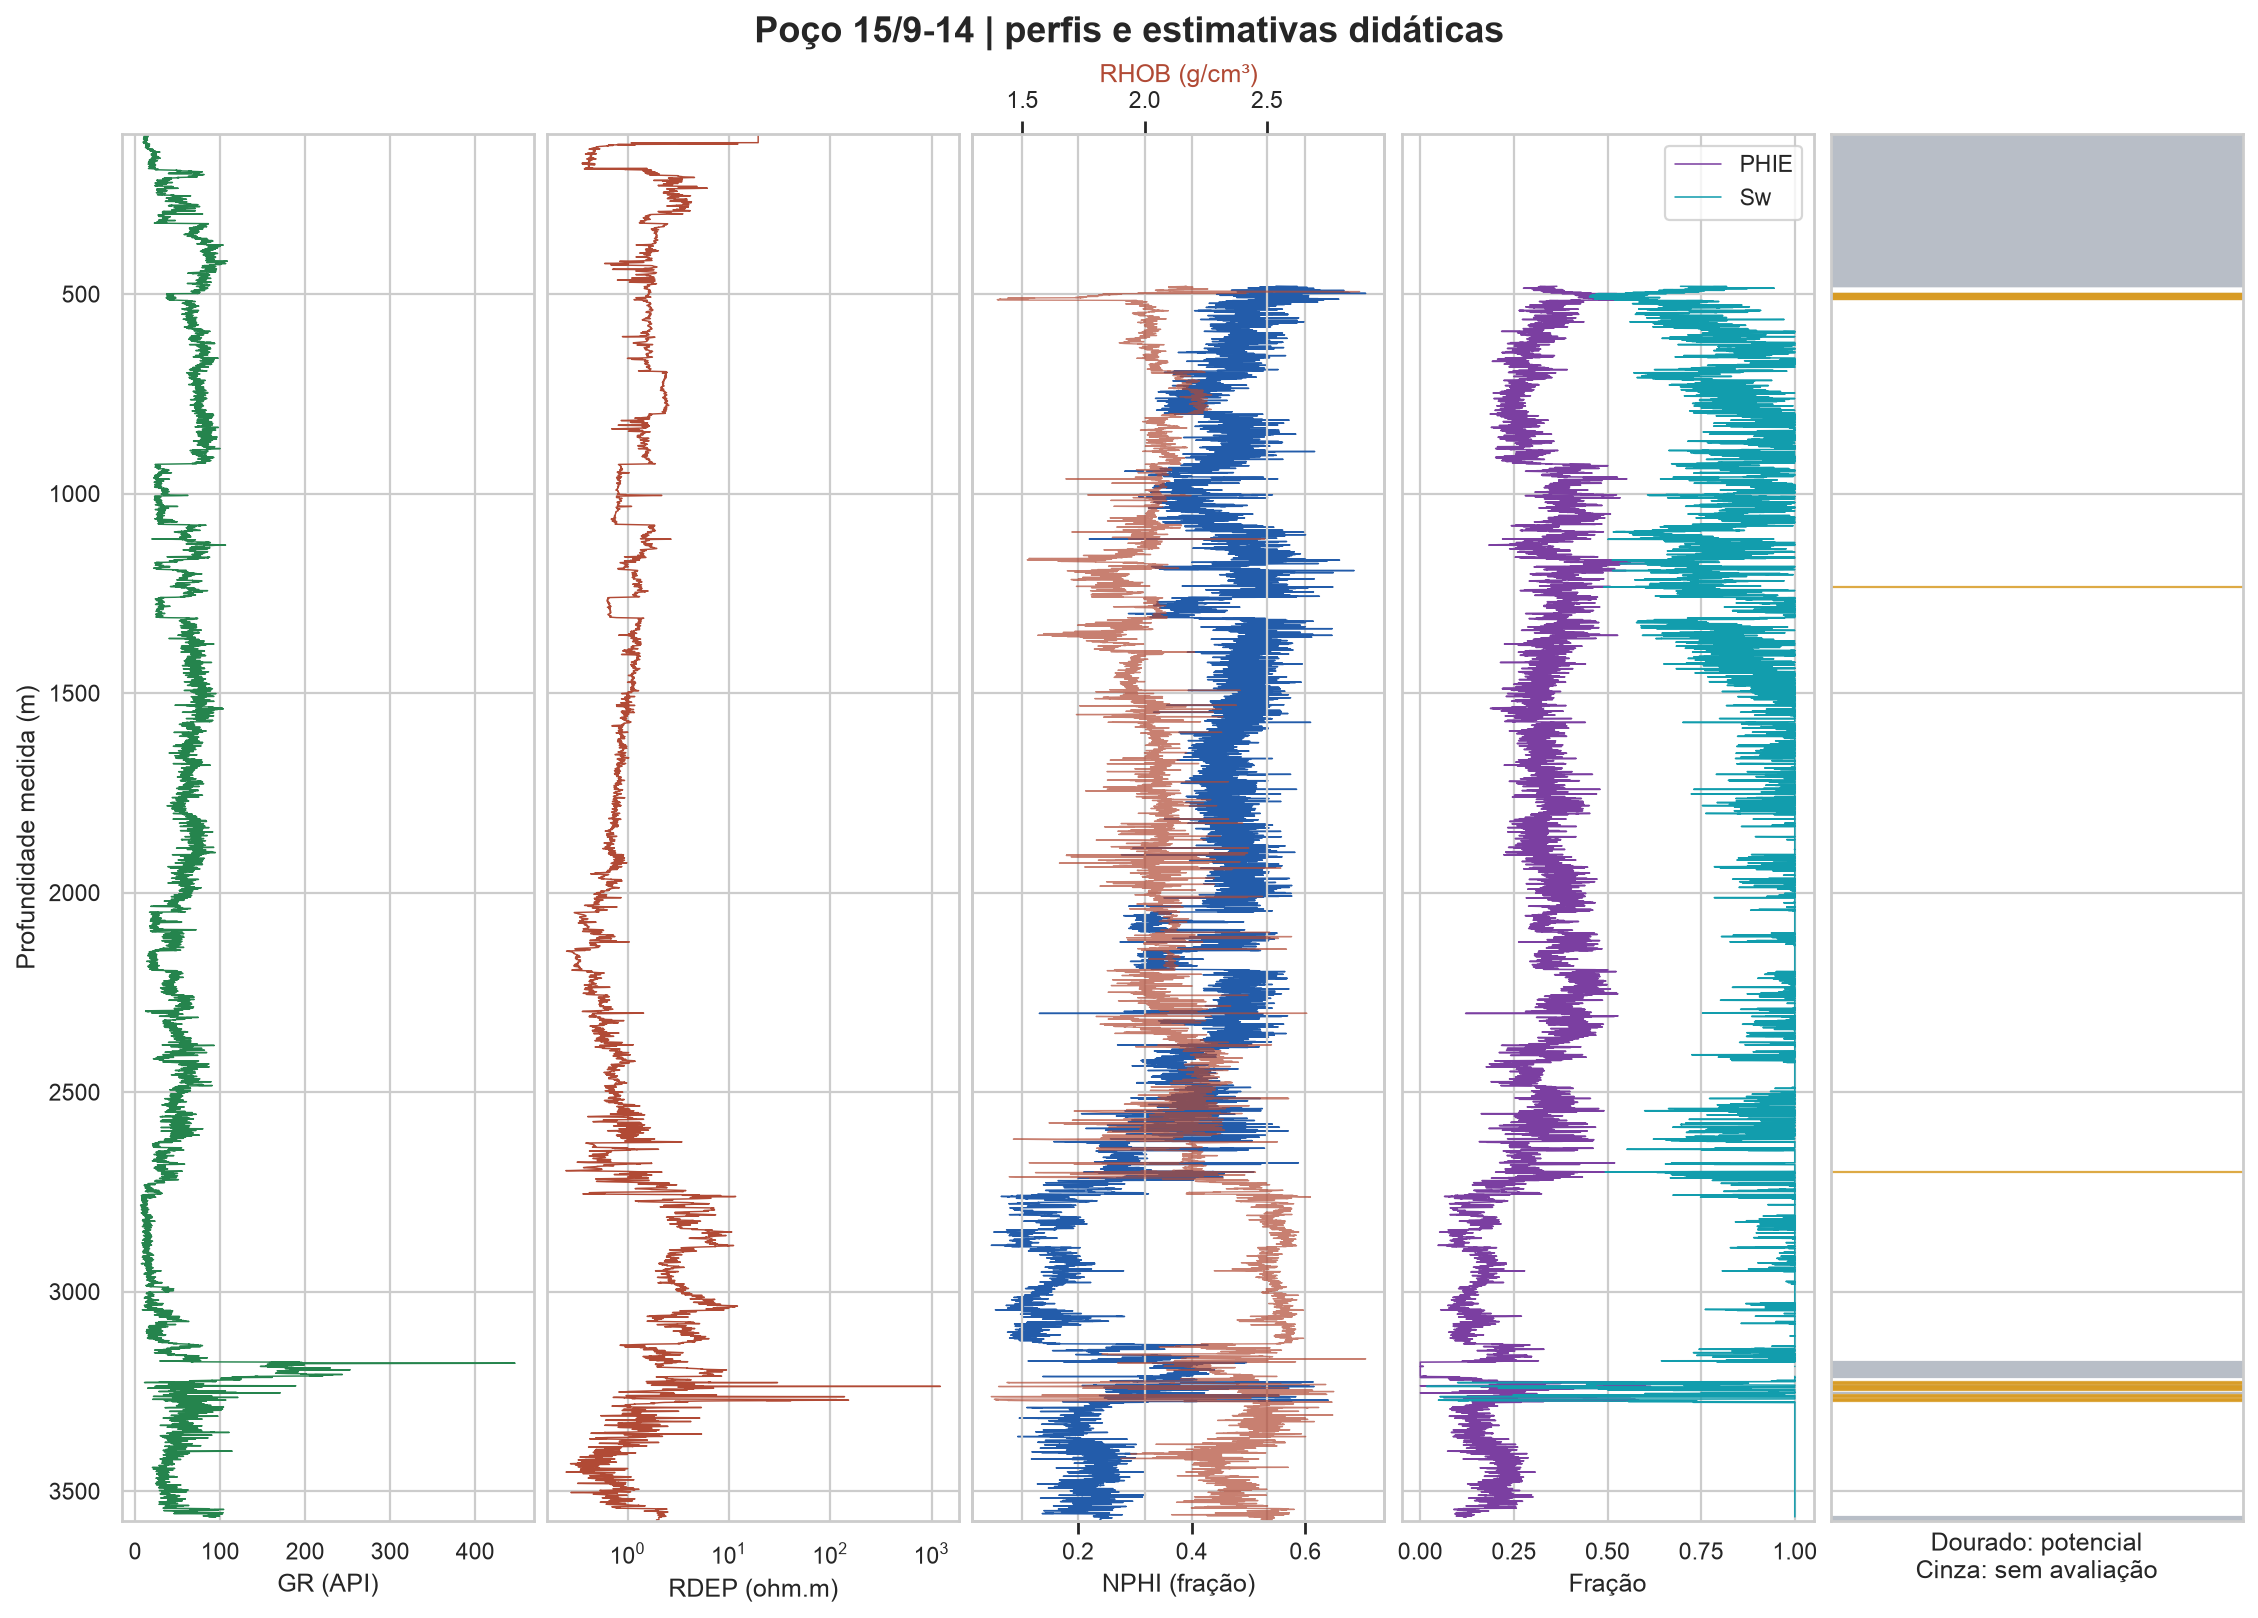

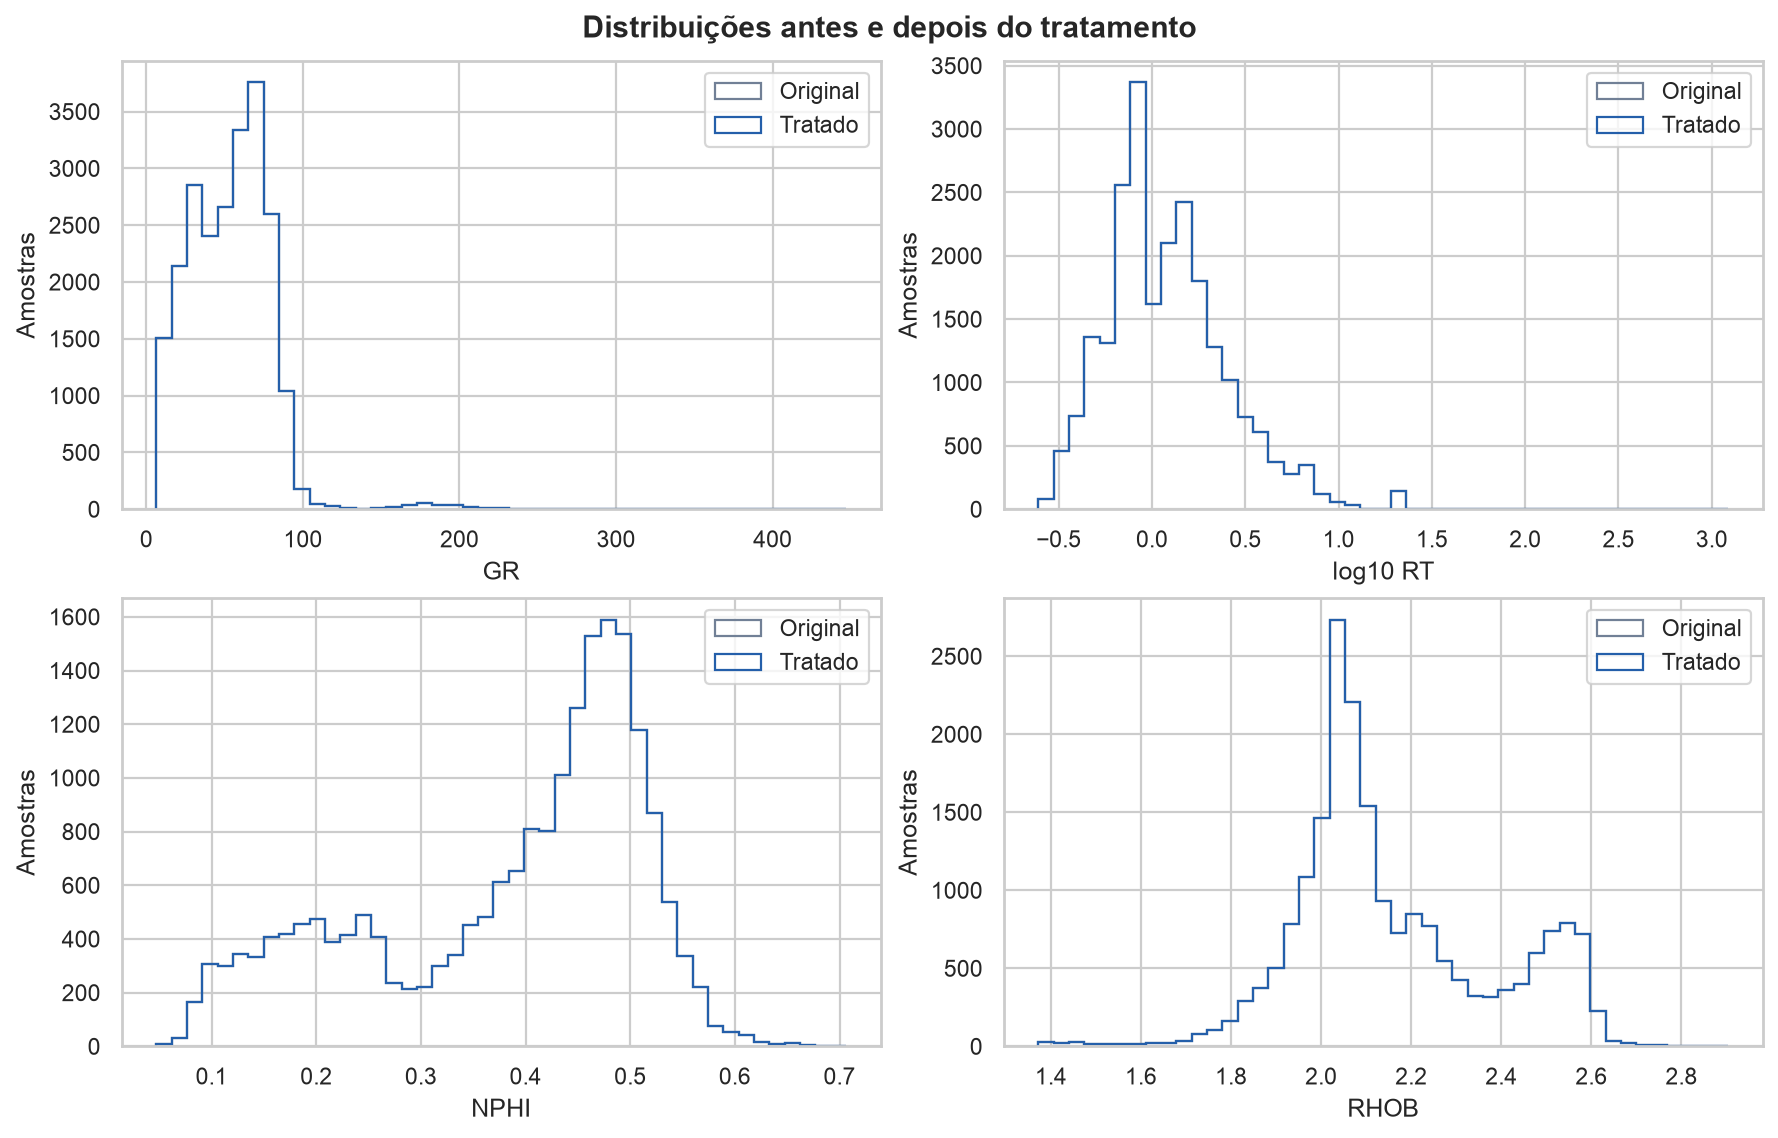

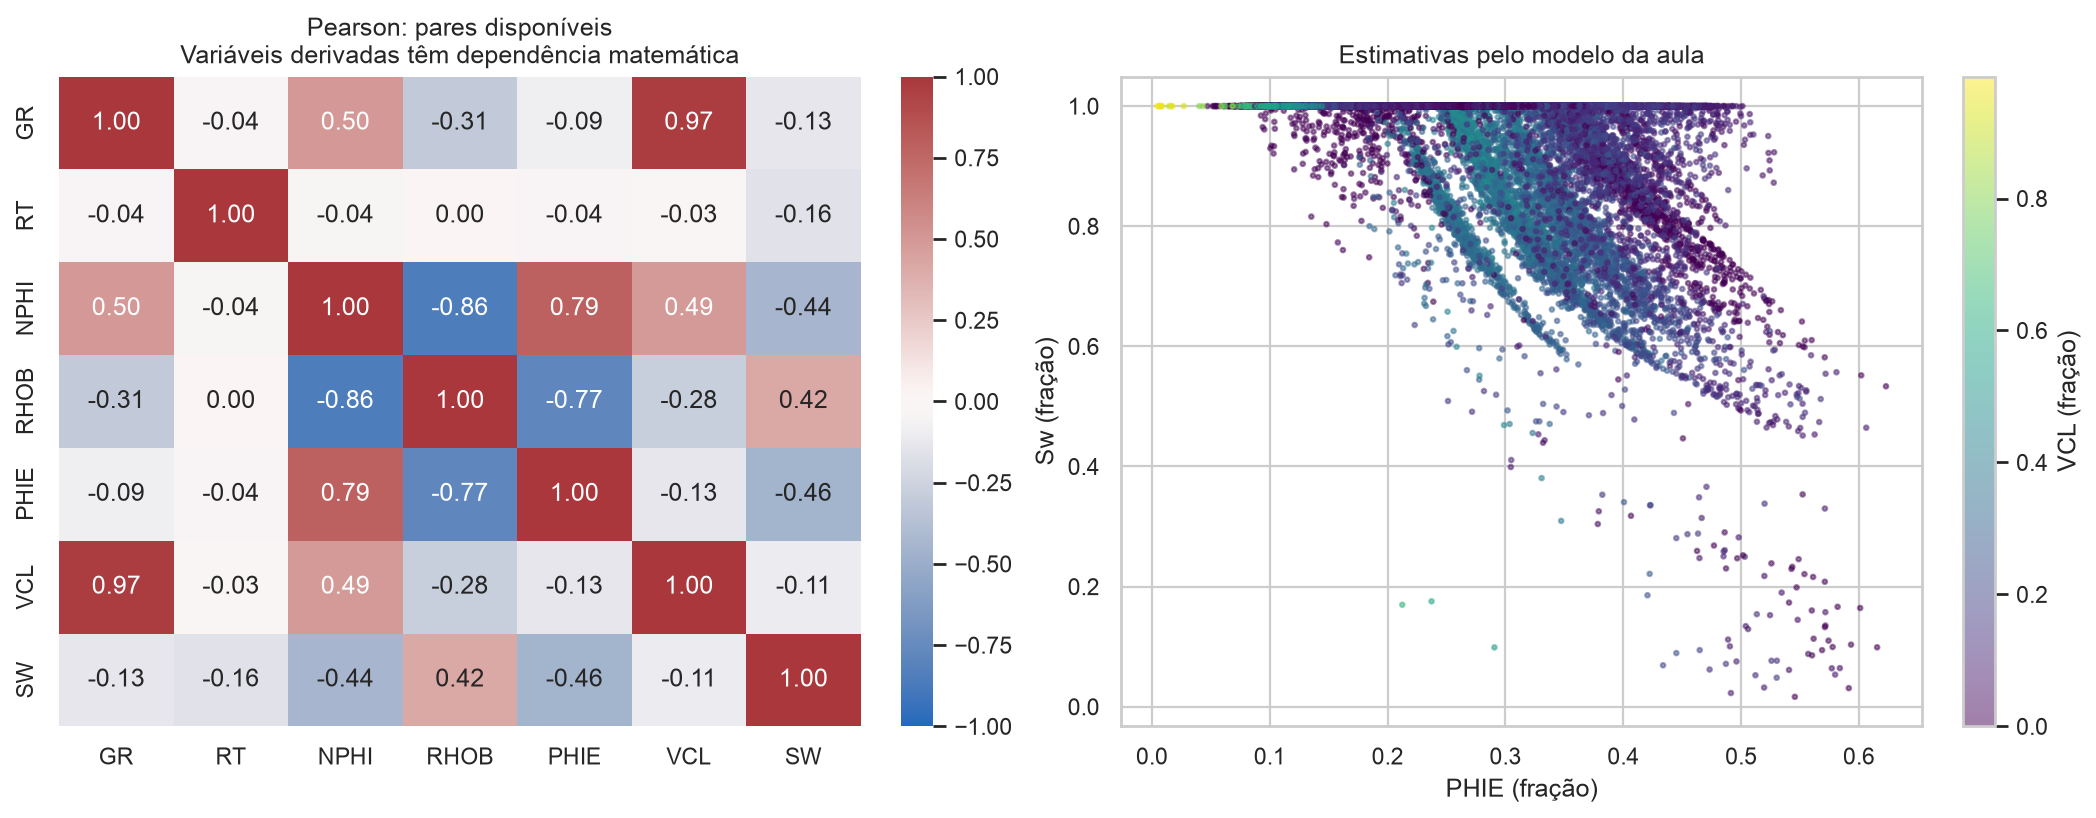

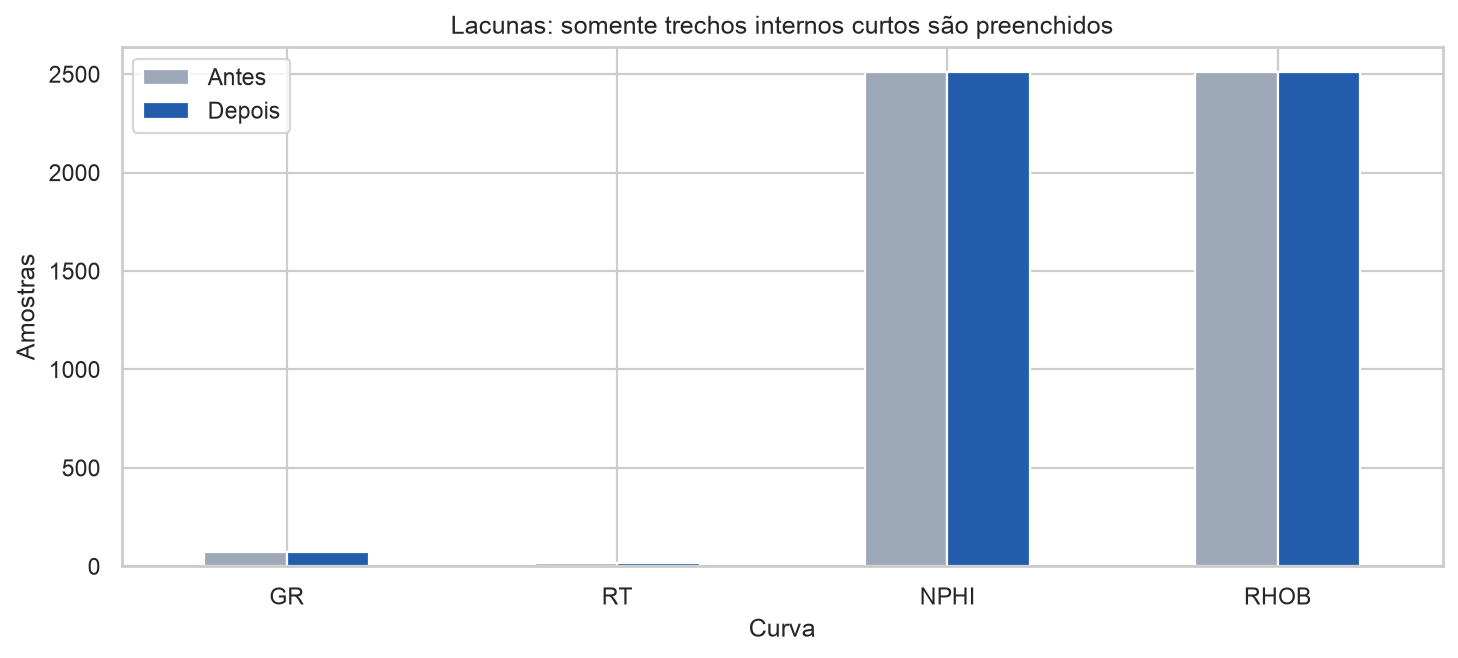

In [9]:
figuras = gerar_graficos(bruto, dados, auditoria, intervalos, BASE/'resultados'/'figuras', meta)
for figura in figuras:
    display(Image(filename=str(figura), width=1000))

## 9. Exportação reproduzível e relatório
A mesma sequência é executada pelo programa, gerando CSVs, JSON, figuras e relatório HTML/Markdown. A execução abaixo também confirma que o programa completo funciona sem depender de variáveis anteriores do notebook.

In [10]:
resultado_programa = executar()
assert resultado_programa['resumo'] == resumo
print('Resultados gravados em:', BASE / 'resultados')
display(Markdown((BASE/'resultados'/'relatorio.md').read_text(encoding='utf-8')))

Resultados gravados em: /Users/jrschmitt/UDESC/2026-2/OPIA/AA2/resultados


# OPIA — Atividade Avaliativa 2

## Análise do poço 15/9-14 — FORCE 2020

Arquivo: **15_9-14.las**. Grupo: **preencher integrantes e conferir exclusividade no Moodle**.
Entrega informada: **16/09/2026 às 14h**.

## Resultado

Foram lidas 22,875 amostras, entre 98.804 e
3575.652 m de profundidade medida (MD).
Após tratamento, 20,050 amostras permitem avaliar os critérios.
A soma dos trechos que atendem aos cortes é **19.152 m MD**,
ou **0.63%** da extensão avaliável de 3047.600 m MD.
Foram encontrados 22 intervalos contíguos;
7 atingem 1.0 m MD.
Essas espessuras são comprimentos ao longo do poço; não são espessuras verticais verdadeiras.

## Dados e método

Fonte: https://doi.org/10.5281/zenodo.4351156. Documentação: https://github.com/bolgebrygg/Force-2020-Machine-Learning-competition.
O registro descreve dados já parcialmente limpos e despiculados; nosso “original” é o LAS
distribuído pelo FORCE, não o registro instrumental primário.
Licenças informadas no registro: CC BY 4.0 e origem sob NOLD 2.0.
SHA-256: 45128f4070ffa50c707f98383ce498922a1c26a77cf224f1384cdf973f397b3a.
RDEP foi associado a RT. Unidades verificadas no cabeçalho: profundidade em m,
GR em gAPI, RDEP em ohm.m, NPHI em m3/m3 e RHOB em g/cm3.

O valor NULL é convertido em ausente. A malha de profundidade é preservada.
Limites físicos de triagem: GR >= 0; RT > 0; -0,15 <= NPHI <= 1; 1 <= RHOB <= 4.
Esses limites são amplos e não substituem controle instrumental.
O método IQR sinaliza extremos (log10 para RT), sem excluí-los automaticamente.
Só são interpoladas lacunas internas cuja distância entre os pontos válidos vizinhos
seja no máximo 0.5 m. Não se extrapolam as extremidades.

## Equações e hipóteses

VCL = clip((GR - 30.0) / (150.0 - 30.0), 0, 1).
PHIE = NPHI × (1 - VCL), seguindo a rotina do Colab; resultados fora de [0,1] ficam ausentes.
Sw_bruta = [a × Rw / (PHIE^m × RT)]^(1/n), com a=1.0,
m=2.0, n=2.0 e Rw=0.1 ohm.m.
Sw é limitada a [0,1], mantendo Sw_bruta e uma indicação dos 11783 valores acima de 1.
Porosidade zero ou negativa não recebe valor artificial para calcular Archie.
SH = 1 - Sw; BVW = PHIE × Sw.

O exemplo alternativo do slide é exportado separadamente:
PHID = (rho_matriz - RHOB)/(rho_matriz - rho_fluido);
PHI_ND_EXEMPLO_SLIDE = (NPHI + PHID)/2.
Ele não é usado para selecionar intervalos. Não se misturam as duas estimativas.

Cortes de seleção: PHIE > 0.12; Sw < 0.5; VCL < 0.4.
São hipóteses didáticas, não valores calibrados para este poço.
Todas as quatro curvas devem estar disponíveis para a avaliação.
Cada amostra representa uma célula delimitada pelos pontos médios vizinhos,
truncada no início/fim do registro. Saltos maiores que 1,5 vezes o passo mediano quebram
intervalos e não recebem espessura. O denominador da fração potencial contém somente
células avaliáveis. Intervalos menores que o mínimo continuam no total e são identificados na tabela.

## Interpretação geológica e limites

Nesta execução, **74 das 126 amostras selecionadas**
estão classificadas como carvão (código 90000) no próprio FORCE.
Portanto, os 19.152 m são somente o resultado bruto dos cortes didáticos,
não uma estimativa validada de espessura produtora de petróleo.
A comparação litológica está em `comparacao_litologica.csv`.
Os intervalos que atingem a espessura mínima estão entre 3225.976 e 3274.312 m MD, em trechos separados, conforme a tabela.
As porosidades estimadas elevadas nesses trechos devem motivar revisão de litologia e resposta instrumental.

Os trechos selecionados apresentam, segundo as hipóteses adotadas, menor resposta relativa
de GR, porosidade estimada suficiente e resposta de resistividade compatível com Sw menor.
Isso indica candidatos a investigação petrofísica; não comprova hidrocarbonetos nem produtividade.
GR isolado não determina litologia: minerais radioativos e a composição da formação afetam o sinal.
Os códigos litológicos fornecidos no LAS foram preservados como referência e não gerados por cortes de GR.
PHIE baseada apenas em NPHI e GR é uma aproximação; matriz, argila e fluidos podem alterar as respostas.
Archie é uma aproximação para rochas limpas; argila condutiva limita sua aplicação.
Rw e parâmetros de Archie precisam de calibração, e a análise de sensibilidade mostra seu impacto.
Correlações envolvendo PHIE, VCL e Sw refletem também as próprias fórmulas e não comprovam causalidade.
Não há treinamento de aprendizado de máquina: esta atividade prepara e interpreta os dados.

## Recomendações técnicas

Revisar os maiores intervalos na tabela junto a CALI, DRHO e demais curvas originais.
Conferir litologia de referência, efeitos de argila/gás e condições de poço.
Calibrar extremos de GR, Rw e parâmetros de Archie com informações independentes.
Comparar intervalos com e sem amostras interpoladas antes de qualquer decisão operacional.
Conferir a disponibilidade do LAS entre os grupos antes da entrega.

## Referências

- Dataset e licenças: https://doi.org/10.5281/zenodo.4351156
- Documentação FORCE: https://github.com/bolgebrygg/Force-2020-Machine-Learning-competition
- Chave de códigos litológicos e confiança: https://thinkonward.com/app/c/challenges/force-well-logs
- Eduardo Paiva, UDESC, Aula 3, slides e rotinas: https://colab.research.google.com/drive/1NhK84WwXNiG4HQSUbKZ0pUcT5ezVX7Xx
- Dados sintéticos usados apenas como referência: https://colab.research.google.com/drive/1mm2gUmYbqO4MBcEgLr2LVAKkRSTvLGRZ
- Equação de Archie e contexto: https://glossary.slb.com/en/terms/a/archie_equation


## 10. Revisão do grupo
- Conferir os intervalos selecionados e discutir as hipóteses do relatório.
- Integrantes: Leandro Alex Zucco; Gustavo Mendes Rodrigues; Jair Antonio Schmitt Junior.
- Verificar se `15_9-14.las — FORCE 2020` está disponível para o grupo e registrar no Moodle.
- Revisar o formato de entrega. Enviar código, notebook e os dados/resultados necessários; não enviar `.venv`.

### Referências
- [FORCE 2020 — DOI e licença](https://doi.org/10.5281/zenodo.4351156)
- [Documentação FORCE](https://github.com/bolgebrygg/Force-2020-Machine-Learning-competition)
- [Colab da Aula 3 — Eduardo Paiva, UDESC](https://colab.research.google.com/drive/1NhK84WwXNiG4HQSUbKZ0pUcT5ezVX7Xx)
- PDF da Aula 3, presente nesta pasta.
- [Equação de Archie — SLB](https://glossary.slb.com/en/terms/a/archie_equation)